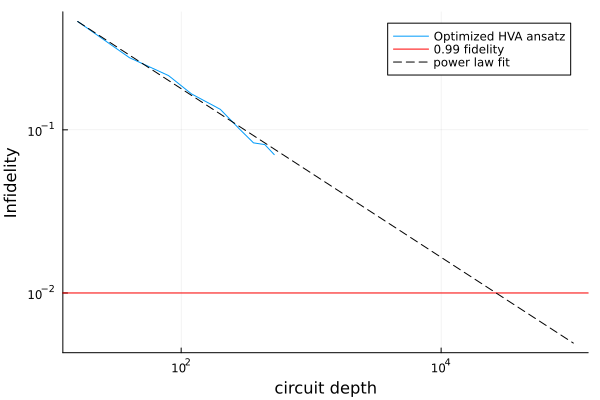

fidelity 0.01 at: 26480.898919797964 depth


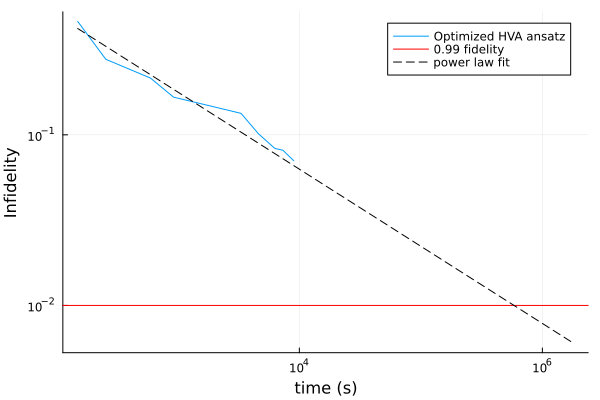

fidelity 0.01 at: 6.756658583379995 days


In [45]:
using CSV, DataFrames
using Plots
using LsqFit

func(x,p) = p[1].*x.^(p[2])

path = "/home/jek354/research/ML-signproblem/experimenting/ed/benchmarks/hva_parameter_sweep_N_5_4_4x3_u60_eigref"
df = nothing
for file in readdir(path)
    if endswith(file, "_gpu.csv")
        df_tmp = CSV.read(joinpath(path, file), DataFrame)
        if df === nothing
            df = df_tmp
        else
            append!(df, df_tmp)
        end
    end
end
sort!(df, :n_params)

fit = curve_fit(func, df.n_layers*8, df.infidelity, [1.0, -1.0])
p = plot(df.n_layers*8, df.infidelity, label="Optimized HVA ansatz", ylabel="Infidelity", xlabel="circuit depth", yscale=:log10, xscale=:log10)
hline!(p, [0.01], label="0.99 fidelity", c="red")
x = LinRange(minimum(df.n_layers*8), maximum(df.n_layers*8)*200,200)
plot!(p, x, func(x, fit.param), label="power law fit", c="black", linestyle=:dash)
display(p)
target_fidelity = 0.01
println("fidelity $target_fidelity at: $((target_fidelity/fit.param[1])^(1/fit.param[2])) depth")


fit = curve_fit(func, df.elapsed_s, df.infidelity, [1.0, -1.0])
p = plot(df.elapsed_s, df.infidelity, label="Optimized HVA ansatz", ylabel="Infidelity", xlabel="time (s)", yscale=:log10, xscale=:log10)
hline!(p, [0.01], label="0.99 fidelity", c="red")
x = LinRange(minimum(df.elapsed_s), maximum(df.elapsed_s)*200,200)
plot!(p, x, func(x, fit.param), label="power law fit", c="black", linestyle=:dash)
display(p)
target_fidelity = 0.01
println("fidelity $target_fidelity at: $((target_fidelity/fit.param[1])^(1/fit.param[2])/60/60/24) days")
